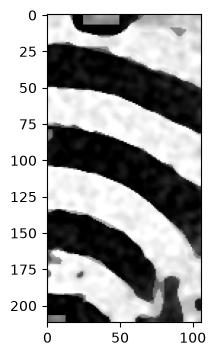

In [11]:
%matplotlib inline
import pickle
import matplotlib.pyplot as plt

with open("./misc/history-noFrame.pkl", "rb") as f:
    history = pickle.load(f)

plt.figure(figsize=(2, 4))
plt.imshow(history['params'][0], cmap='gray_r')
plt.show()

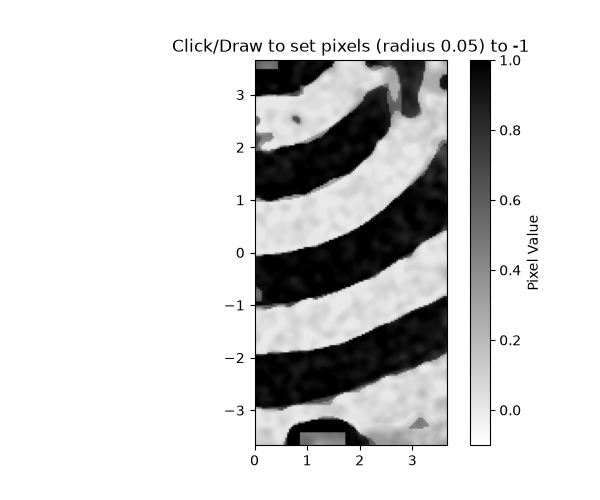

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

class InteractiveCanvas:
    def __init__(self, array, extent, radius=0.05):
        # We store a reference to the original array. 
        # Modifying self.array modifies the global array in place.
        self.array = array
        self.extent = extent
        self.radius = radius
        self.is_drawing = False
        
        # 1. Extract physical dimensions and grid shapes
        N, M = self.array.shape
        xmin, xmax, ymin, ymax = self.extent
        
        # 2. Create physical coordinate grids for distance calculation
        # X maps to columns (M), Y maps to rows (N)
        x_coords = np.linspace(xmin, xmax, M)
        y_coords = np.linspace(ymin, ymax, N)
        self.X, self.Y = np.meshgrid(x_coords, y_coords)
        
        # 3. Setup the plot
        self.fig, self.ax = plt.subplots(figsize=(6, 5))
        # Set vmin=-1 and vmax=1 so the -1 values stand out strongly against the 0-1 values
        self.im = self.ax.imshow(self.array, extent=self.extent, origin='lower', 
                                 vmin=-0.1, vmax=1, cmap='gray_r')
        
        self.fig.colorbar(self.im, ax=self.ax, label="Pixel Value")
        self.ax.set_title(f"Click/Draw to set pixels (radius {self.radius}) to -1")
        
        # 4. Connect the mouse events
        self.fig.canvas.mpl_connect('button_press_event', self.on_press)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)
        
        plt.show()

    def update_pixels(self, x_click, y_click):
        # Ignore events outside the axes
        if x_click is None or y_click is None:
            return
            
        # Calculate Euclidean distance from the click to all pixel coordinates
        dist = np.sqrt((self.X - x_click)**2 + (self.Y - y_click)**2)
        
        # Create a boolean mask of pixels within the radius
        mask = dist <= self.radius
        
        # Update the array and the visual plot if any pixels fall within the radius
        if np.any(mask):
            self.array[mask] = 1.5           # Mutates the actual array in memory
            self.im.set_data(self.array)      # Updates the image data
            self.fig.canvas.draw_idle()       # Requests a canvas redraw

    def on_press(self, event):
        if event.inaxes != self.ax: return
        self.is_drawing = True
        self.update_pixels(event.xdata, event.ydata)

    def on_motion(self, event):
        if not self.is_drawing: return
        if event.inaxes != self.ax: return
        self.update_pixels(event.xdata, event.ydata)

    def on_release(self, event):
        self.is_drawing = False


# ==========================================
# Example Usage
# ==========================================

# Create an N x M array (e.g., 200x200) with values from 0 to 1
# N, M = 200, 200
# my_array = np.random.rand(N, M)

with open("./misc/history-noFrame.pkl", "rb") as f:
    history = pickle.load(f)
array = history['params'][0]
array -= array.min()
array /= array.max()
    
# Define physical dimensions [xmin, xmax, ymin, ymax]
N, M = array.shape
physical_extent = [0, 7.32/2, -7.32/2, 7.32/2]

# Launch the interactive canvas
canvas = InteractiveCanvas(array, physical_extent, radius=0.05)

In [13]:

with open("./data-noFrame/bones.pkl", "wb") as f:
    pickle.dump(array, f)

In [16]:
array

array([[0.1453005 , 0.12198558, 0.12801115, ..., 0.28202974, 0.28647701,
        0.29841167],
       [0.11406014, 0.09873475, 0.10258229, ..., 0.24868846, 0.25050054,
        0.2688845 ],
       [0.10583992, 0.09033901, 0.09257154, ..., 0.21853893, 0.21644092,
        0.23442253],
       ...,
       [0.60083049, 0.58286659, 0.55634334, ..., 0.16804516, 0.21306617,
        0.23819494],
       [0.61646828, 0.60066273, 0.57600163, ..., 0.19397819, 0.25165798,
        0.28181281],
       [0.62656501, 0.61299743, 0.59051035, ..., 0.22081428, 0.27871775,
        0.31337191]], shape=(212, 106))

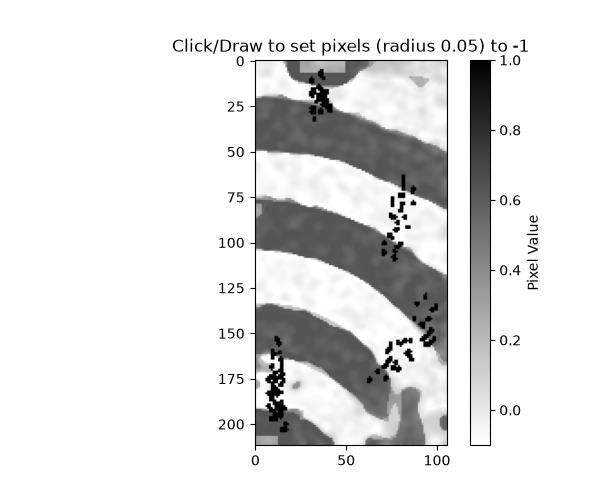

In [ ]:
array_mod = array.copy()
mask = array == -1
array_mod[mask] = 1
array_mod[~mask] = 0
with open("./data-noFrame/bones.pkl", "rb") as f:
    array = pickle.load(f)

plt.imshow(array, cmap='gray_r')
plt.show()

In [119]:
array_mod = array.copy()
mask = array == -1
array_mod[mask] = 1
array_mod[~mask] = 0

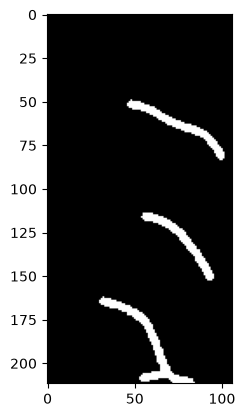

In [121]:
%matplotlib inline
plt.imshow(array_mod,cmap='gray')
plt.show()

with open('mask3.pkl', 'wb') as f:
    pickle.dump(array_mod, f)

In [79]:
import numpy as np
import autograd
import autograd.numpy as anp
from autograd.scipy.signal import convolve as ag_convolve
from autograd.tracer import getval

import gdstk
import tidy3d as td
import tidy3d.web as web

td.config.logging.level = "ERROR"

# =====================================================================
# 1. CONSTANTS & PARAMETERS
# =====================================================================
C_C0 = td.C_0
C_FS = 1e-15
C_THZ = 1e12

WVL_0 = 2.9013670   
FREQ_0 = C_C0 / WVL_0

FWIDTH = 7 * C_THZ
FREQ_RANGE = (FREQ_0 - FWIDTH/2, FREQ_0 + FWIDTH/2)        
WVL_RANGE = (C_C0 / FREQ_RANGE[1], C_C0 / FREQ_RANGE[0])

N_TANTALA = 2.036
EPS_TANTALA = N_TANTALA**2

THICKNESS = 0.8     
WG_LENGTH = 7
WG_WIDTH = 1.7          

# Inverse design region (Assumes the hole in your GDS is centered at x=0, y=0)
REGION_LENGTH = 7   
REGION_WIDTH = 7    
REGION_GRID_SIZE = 0.4  
nx = int(REGION_LENGTH / REGION_GRID_SIZE)
ny = int(REGION_WIDTH / REGION_GRID_SIZE)

BEAM_ANGLE_DEG = 0
BEAM_WAIST = 2.62
BEAM_WAIST_DISTANCE = 2

GDS_FILENAME = "coupler_frame.gds"
GDS_LAYER = 0
GDS_DATATYPE = 0

# =====================================================================
# 2. LOAD STATIC FRAME FROM GDS
# =====================================================================
def load_frame_from_gds(filename):
    global bbox
    lib = gdstk.read_gds(filename)
    cell = lib.cells[0]

    x_min, y_min = float('inf'), float('inf')
    x_max, y_max = float('-inf'), float('-inf')
    for p in cell.get_polygons():
        bbox = p.bounding_box()
        x_min, y_min = min(x_min, bbox[0][0]), min(y_min, bbox[0][1])
        x_max, y_max = max(x_max, bbox[1][0]), max(y_max, bbox[1][1])

    bbox = (x_min, y_min), (x_max, y_max)
    print(f"Bounding box: {bbox}")
    geo = td.Geometry.from_gds(
        gds_cell=cell, 
        slab_bounds=[-THICKNESS/2, THICKNESS/2],
        axis=2, 
        gds_layer=0
    )
    
    structures = [
        td.Structure(
            geometry=geo,
            medium=td.Medium(permittivity=EPS_TANTALA),
            name='GratingCoupler',
        )
    ]  

    return structures

FRAME_STRUCTURES = load_frame_from_gds(GDS_FILENAME)


# =====================================================================
# 3. FILTERING & BINARIZATION 
# =====================================================================
MIN_FEATURE_SIZE = 0.1 
FILTER_RADIUS = max(MIN_FEATURE_SIZE, REGION_GRID_SIZE * 1.5)

def get_conic_filter(radius, dx, dy):
    rx, ry = int(np.ceil(radius / dx)), int(np.ceil(radius / dy))
    x, y = np.arange(-rx, rx + 1) * dx, np.arange(-ry, ry + 1) * dy
    X, Y = np.meshgrid(x, y)
    kernel = np.maximum(0, radius - np.sqrt(X**2 + Y**2))
    return kernel / np.sum(kernel)

CONIC_KERNEL = get_conic_filter(FILTER_RADIUS, REGION_GRID_SIZE, REGION_GRID_SIZE)

def apply_topology_constraints(params, beta):
    filtered = ag_convolve(params, CONIC_KERNEL, mode='same')
    density = 0.5 * (anp.tanh(beta * filtered) + 1.0)
    return density

# =====================================================================
# 4. OMNIDIRECTIONAL CONNECTIVITY
# =====================================================================
# Mask identifying the 4 edges of the inverse design region where it touches the frame
BOUNDARY_MASK = np.zeros((nx, ny), dtype=bool)
BOUNDARY_MASK[0, :] = True
BOUNDARY_MASK[-1, :] = True
BOUNDARY_MASK[:, 0] = True
BOUNDARY_MASK[:, -1] = True

def connectivity_penalty(density_matrix, iterations=100):
    kernel = anp.array([[0.0, 0.25, 0.0], 
                        [0.25, 0.0, 0.25], 
                        [0.0, 0.25, 0.0]])
    
    heat = anp.zeros_like(density_matrix)
    for _ in range(iterations):
        # Inject heat from the surrounding solid frame
        heat = anp.where(BOUNDARY_MASK, 1.0, heat)
        h_diff = ag_convolve(heat, kernel, mode='same')
        heat = h_diff * density_matrix
        
    heat = anp.where(BOUNDARY_MASK, 1.0, heat)
    penalty = anp.sum(density_matrix * (1.0 - heat)**2)
    return penalty

# =====================================================================
# 5. SIMULATION DEFINITION
# =====================================================================
SIM_CENTER = ((bbox[1][0] + bbox[0][0]) / 2, (bbox[1][1] + bbox[0][1]) / 2, (THICKNESS + 2 + BEAM_WAIST_DISTANCE)/2)
SIM_SIZE = (bbox[1][0] - bbox[0][0] + 2, bbox[1][1] - bbox[0][1] + 2, THICKNESS + 2 + BEAM_WAIST_DISTANCE)

def make_simulation(params, beta):
    density = apply_topology_constraints(params, beta)
    permittivity = 1.0 + (EPS_TANTALA - 1.0) * density
    
    # 1. Inverse Design Medium (Must be aligned with the hole in the GDS!)
    xs = anp.linspace(-REGION_LENGTH/2, REGION_LENGTH/2, nx)
    ys = anp.linspace(-REGION_WIDTH/2, REGION_WIDTH/2, ny)
    zs = anp.array([-THICKNESS/2, THICKNESS/2])
    
    eps_3d = permittivity.reshape((nx, ny, 1))
    eps_3d = anp.repeat(eps_3d, 2, axis=2)
    
    eps_dataset = td.SpatialDataArray(data=eps_3d, coords={"x": xs, "y": ys, "z": zs})
    design_medium = td.CustomMedium(permittivity=eps_dataset)
    
    design_box = td.Box(center=(0, 0, 0), size=(REGION_LENGTH, REGION_WIDTH, THICKNESS))
    design_structure = td.Structure(geometry=design_box, medium=design_medium)
    
    # 2. Simulation Setup
    gaussian_source = td.GaussianBeam(
        center=(0, 0, BEAM_WAIST_DISTANCE),
        size=(3*BEAM_WAIST, 3*BEAM_WAIST, 0),
        angle_theta=BEAM_ANGLE_DEG*np.pi/180,
        pol_angle=np.pi/2,   
        direction="-", 
        waist_radius=BEAM_WAIST,
        waist_distance=-BEAM_WAIST_DISTANCE,
        source_time=td.GaussianPulse(freq0=FREQ_0, fwidth=FWIDTH),
    )
    
    
    # mode_monitor = td.ModeMonitor(
    #     center=(monitor_x, 0, 0),
    #     size=(0, WG_WIDTH + 3*WVL_0, THICKNESS + 3*WVL_0),
    #     freqs=[FREQ_0],
    #     mode_spec=td.ModeSpec(num_modes=1, target_neff=N_TANTALA),
    #     name="mode_coupling"
    # )
    

    sim = td.Simulation(
        center=SIM_CENTER,
        size=SIM_SIZE,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=15),
        
        # Boolean Priority: Unpacking FRAME_STRUCTURES first. 
        # Since design_structure is last, its "Air" voids will carve through the solid frame!
        structures=[*FRAME_STRUCTURES, design_structure], 
        sources=[gaussian_source],
        # monitors=[mode_monitor],
        run_time=2e-12,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML())
    )
    
    return sim, density

def objective_fn(params, beta):
    sim, density = make_simulation(params, beta)    
    sim_data = web.run(sim, task_name="grating_coupler_opt", verbose=False)
    
    # Assuming the wave travels in the positive x direction towards the monitor
    amps = sim_data["mode_coupling"].amps.sel(direction="+").values
    coupling_efficiency = anp.sum(anp.abs(amps)**2)
    
    island_penalty = connectivity_penalty(density, iterations=nx)
    penalty_weight = 0.5 
    
    loss = -coupling_efficiency + (penalty_weight * island_penalty)
    
    print(f"  --> Beta: {beta:.2f} | Eff: {float(getval(coupling_efficiency)):.4f} | Pen: {float(getval(island_penalty)):.4f}")
    
    return loss

Bounding box: ((-3.75, -3.75), (10.75, 3.75))


<Axes: title={'center': 'cross section at z=0.00 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

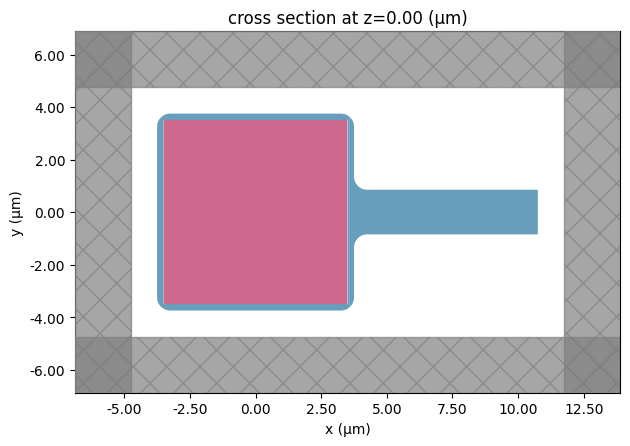

In [80]:
np.random.seed(114514)
params = np.random.uniform(-0.1, 0.1, size=(nx, ny))
sim, _ = make_simulation(params, beta=1.0)
sim.plot(z=0)

In [78]:
import gdstk

def create_photonic_structure(
    square_size: float = 10.0,
    beam_width: float = 2.0,
    beam_length: float = 5.0,
    hole_size: float = 4.0,
    corner_radius: float = 1.5,
    junction_radius: float = 2.0,
    layer: int = 0,
    datatype: int = 0
):
    """
    Creates a GDS structure with a round-edged square, a sharp square hole,
    and a curved junction to a beam on the right side.
    """
    
    if beam_width >= square_size:
        raise ValueError("Beam width must be strictly less than the square size.")
        
    L = square_size
    w = beam_width
    b = beam_length
    
    # 1. Define the vertices of the outer shape (square + attached beam)
    # We trace the perimeter counter-clockwise starting from the top-left
    vertices = [
        (-L/2, L/2),          # v0: Top-left of square
        (-L/2, -L/2),         # v1: Bottom-left of square
        (L/2, -L/2),          # v2: Bottom-right of square (bottom half)
        (L/2, -w/2),          # v3: Junction point (bottom concave corner)
        (L/2 + b, -w/2),      # v4: Bottom-right end of the beam
        (L/2 + b, w/2),       # v5: Top-right end of the beam
        (L/2, w/2),           # v6: Junction point (top concave corner)
        (L/2, L/2)            # v7: Top-right of square (top half)
    ]
    
    # Create the single outer polygon
    outer_poly = gdstk.Polygon(vertices)
    
    # 2. Fillet the corners
    # We pass a list of radii mapping perfectly to the 8 vertices above.
    # Note: if corner_radius + junction_radius is larger than the available edge 
    # between them, gdstk will automatically cap the fillet to prevent errors.
    radii = [
        corner_radius,    # v0: round
        corner_radius,    # v1: round
        corner_radius,    # v2: round
        junction_radius,  # v3: curved junction
        0.0,              # v4: flat beam end
        0.0,              # v5: flat beam end
        junction_radius,  # v6: curved junction
        corner_radius     # v7: round
    ]
    outer_poly.fillet(radii, tolerance=1e-4)
    
    # 3. Create the inner sharp-edged square hole, centered at (0,0)
    hole = gdstk.rectangle(
        (-hole_size/2, -hole_size/2), 
        (hole_size/2, hole_size/2)
    )
    
    # 4. Subtract the hole from the outer polygon
    # gdstk.boolean returns a list of resulting polygons
    final_polygons = gdstk.boolean(
        outer_poly, 
        hole, 
        "not", 
        layer=layer, 
        datatype=datatype
    )
    
    return final_polygons

if __name__ == "__main__":
    # --- Example Usage ---
    
    # Initialize a library and a cell
    lib = gdstk.Library()
    cell = lib.new_cell("MAIN")
    
    # Generate the polygons using custom parameters
    polys = create_photonic_structure(
        square_size=7.5,
        beam_width=1.7,
        beam_length=7,
        hole_size=7,
        corner_radius=0.5,
        junction_radius=0.5
    )
    
    cell.add(*polys)

    # Save the library to a GDSII file
    lib.write_gds("coupler_frame.gds")

In [29]:
(8-1.7)/2/2

1.575